# Appliances Energy Consumption — Five Regression Models

This notebook follows the **same overall dataset/preprocessing/split structure used by the team's first regression notebook**, while using proper cross-validation for hyperparameter selection.

Models implemented here:
1. Decision Tree Regressor
2. Random Forest Regressor
3. Gradient Boosting Regressor
4. Support Vector Regressor (SVR)
5. K-Nearest Neighbors Regressor (KNN)

Target: `Appliances` — appliance energy consumption in Wh.

**Evaluation protocol:** one common 80:20 random train/test split with `random_state=42` is used for all five models. Hyperparameters are selected using cross-validation on the training portion only; the test set is reserved for the final comparison.

This is intentionally aligned with the team's other regression notebook so that the ten models can later be combined into one comparison table.

## 1. Import Required Libraries

In [1]:
import os
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import (
    train_test_split,
    KFold,
    GridSearchCV,
    RandomizedSearchCV,
    cross_val_score
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

RANDOM_STATE = 42
TEST_SIZE = 0.20
CV = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

DATA_PATH = Path("../data/energydata_complete.csv")
MODEL_DIR = Path("../models")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.6f}")

print("Model directory:", MODEL_DIR.resolve())

Model directory: C:\Users\Kartik\OneDrive\Desktop\study\CSE\Semester - 5\ML\case study\models


## 2. Load the Dataset

In [2]:
df = pd.read_csv(DATA_PATH)

print(df.head())
print("\n------------------------------------------\n")
print(f"Number of rows   : {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")
print("\nColumn names:")
print(df.columns.tolist())

                  date  Appliances  lights        T1      RH_1        T2  \
0  2016-01-11 17:00:00          60      30 19.890000 47.596667 19.200000   
1  2016-01-11 17:10:00          60      30 19.890000 46.693333 19.200000   
2  2016-01-11 17:20:00          50      30 19.890000 46.300000 19.200000   
3  2016-01-11 17:30:00          50      40 19.890000 46.066667 19.200000   
4  2016-01-11 17:40:00          60      40 19.890000 46.333333 19.200000   

       RH_2        T3      RH_3        T4      RH_4        T5      RH_5  \
0 44.790000 19.790000 44.730000 19.000000 45.566667 17.166667 55.200000   
1 44.722500 19.790000 44.790000 19.000000 45.992500 17.166667 55.200000   
2 44.626667 19.790000 44.933333 18.926667 45.890000 17.166667 55.090000   
3 44.590000 19.790000 45.000000 18.890000 45.723333 17.166667 55.090000   
4 44.530000 19.790000 45.000000 18.890000 45.530000 17.200000 55.090000   

        T6      RH_6        T7      RH_7        T8      RH_8        T9  \
0 7.026667 84.2566

## 3. Initial Dataset Audit

In [3]:
print("Missing values (total):", df.isnull().sum().sum())
print("\nMissing values per column:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nDataset information:")
df.info()

Missing values (total): 0

Missing values per column:
date           0
Appliances     0
lights         0
T1             0
RH_1           0
T2             0
RH_2           0
T3             0
RH_3           0
T4             0
RH_4           0
T5             0
RH_5           0
T6             0
RH_6           0
T7             0
RH_7           0
T8             0
RH_8           0
T9             0
RH_9           0
T_out          0
Press_mm_hg    0
RH_out         0
Windspeed      0
Visibility     0
Tdewpoint      0
rv1            0
rv2            0
dtype: int64

Duplicate rows: 0

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19735 entries, 0 to 19734
Data columns (total 29 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date         19735 non-null  object 
 1   Appliances   19735 non-null  int64  
 2   lights       19735 non-null  int64  
 3   T1           19735 non-null  float64
 4   RH_1         19735 non-null  floa

## 4. Exploratory Data Analysis — Target and Features

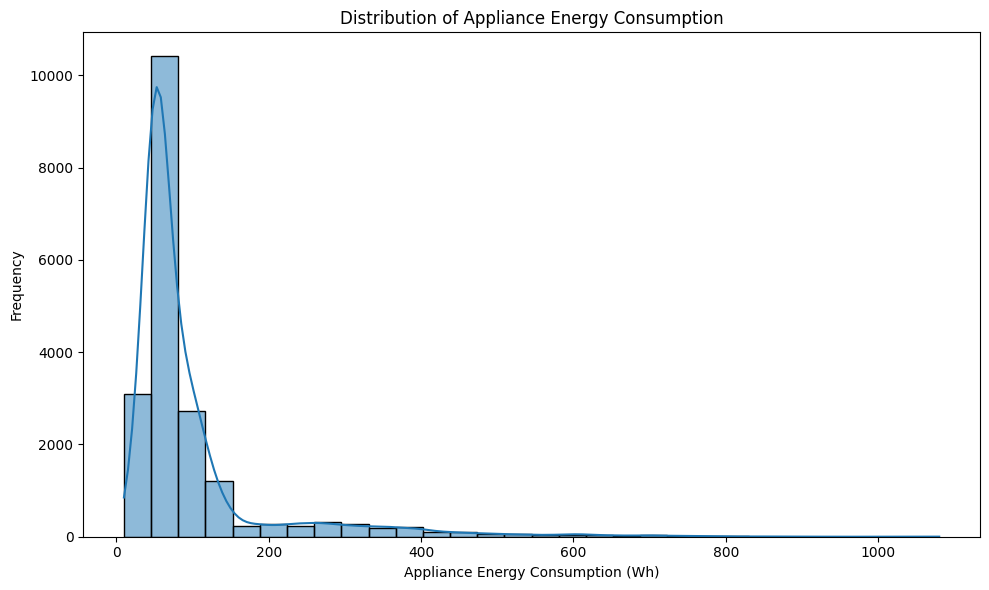

count   19735.000000
mean       97.694958
std       102.524891
min        10.000000
25%        50.000000
50%        60.000000
75%       100.000000
max      1080.000000
Name: Appliances, dtype: float64


In [4]:
plt.figure(figsize=(10, 6))
sns.histplot(df["Appliances"], bins=30, kde=True)
plt.xlabel("Appliance Energy Consumption (Wh)")
plt.ylabel("Frequency")
plt.title("Distribution of Appliance Energy Consumption")
plt.tight_layout()
plt.show()

print(df["Appliances"].describe())

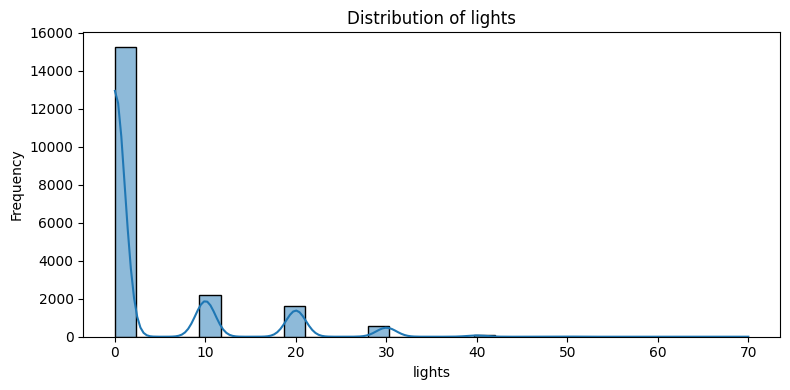

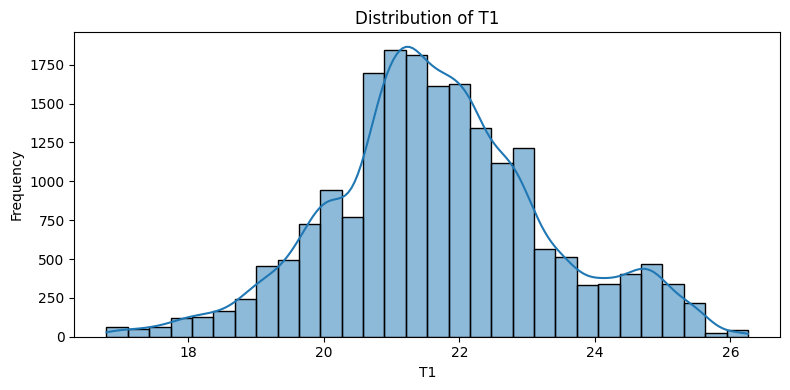

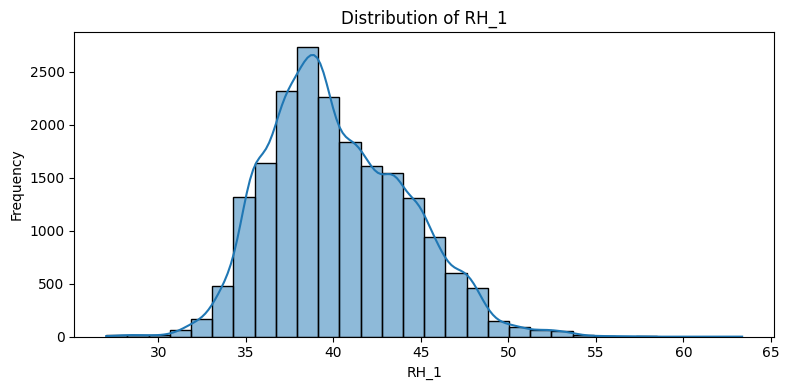

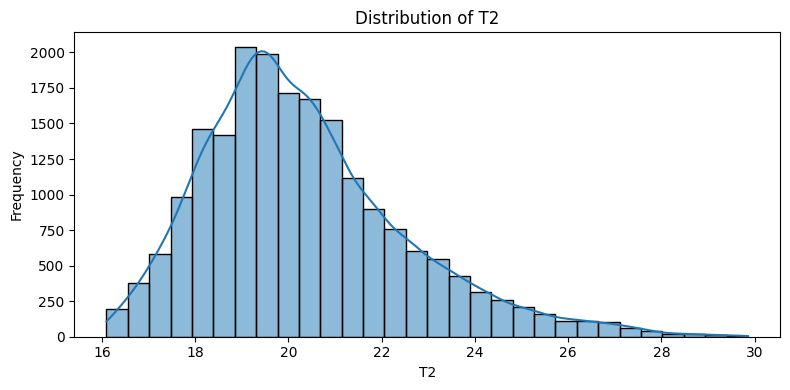

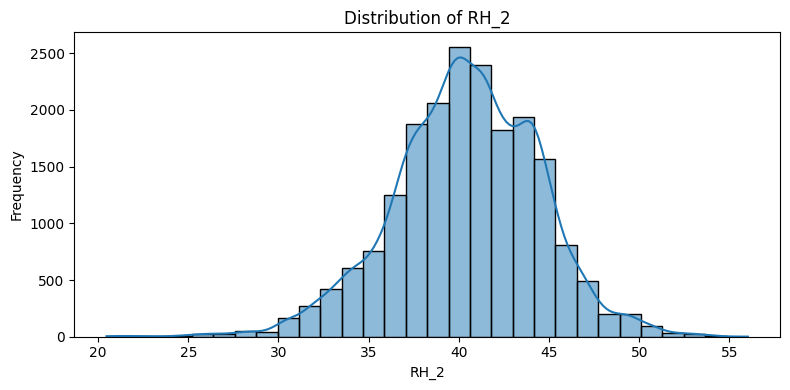

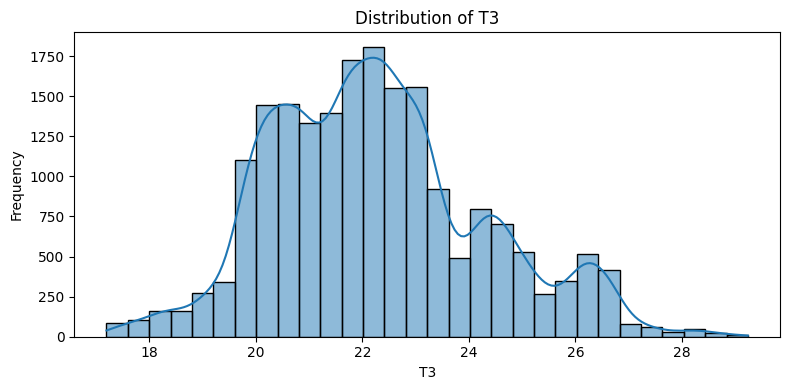

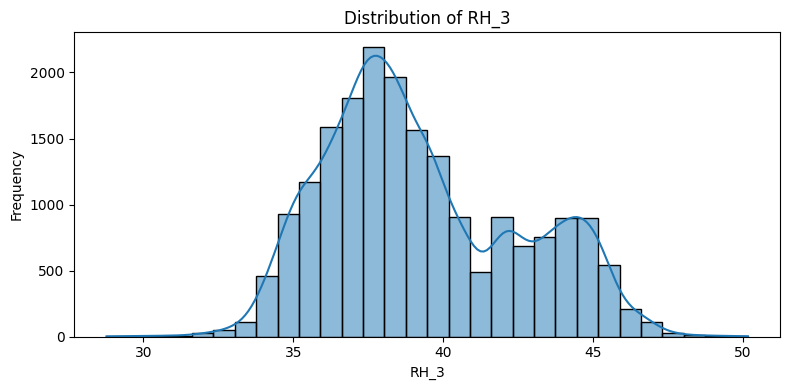

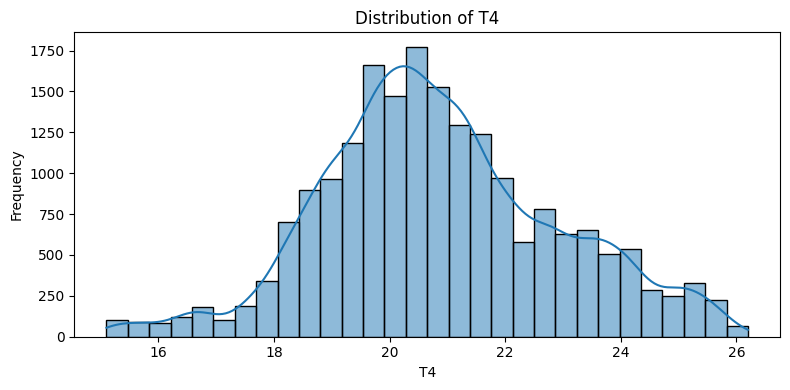

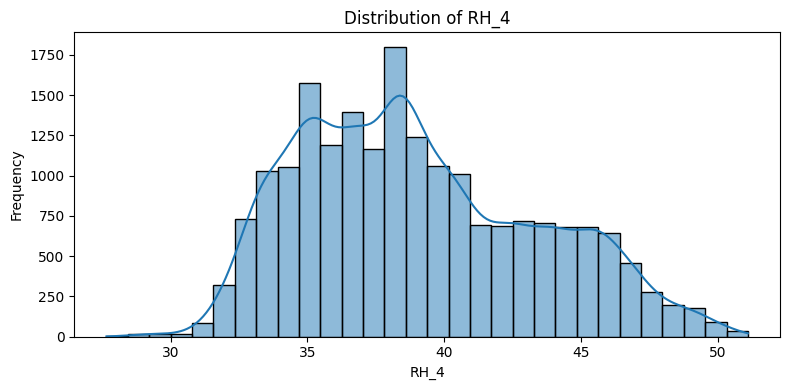

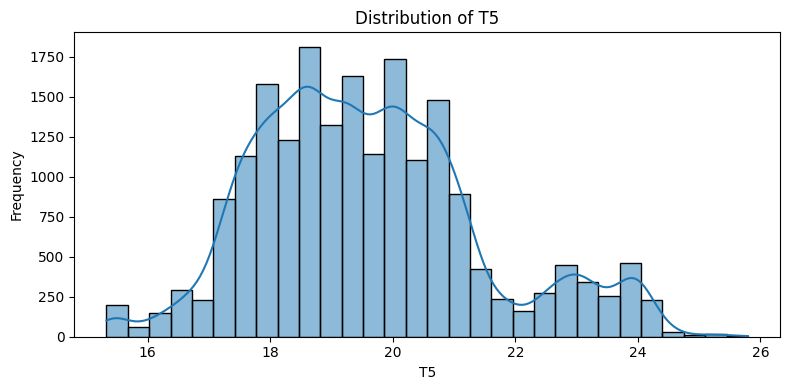

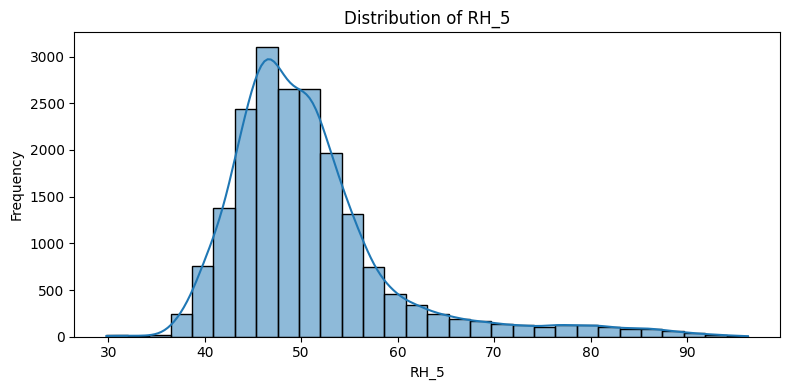

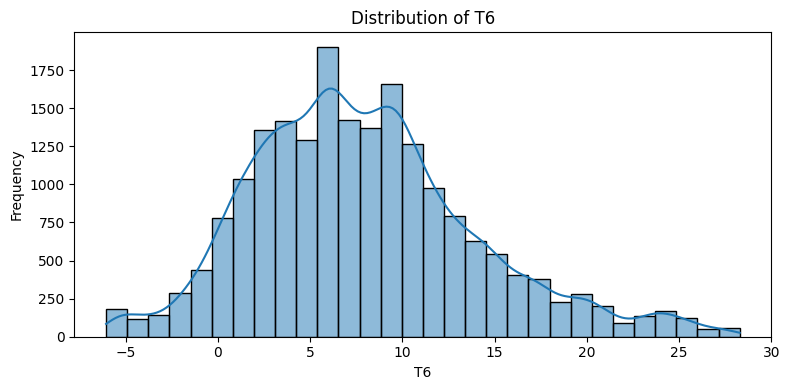

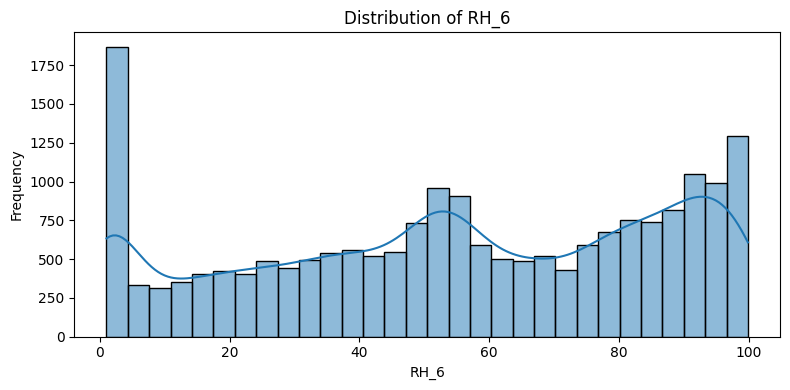

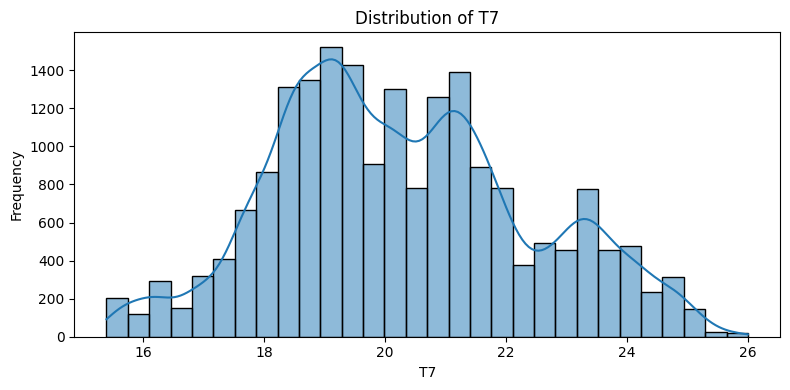

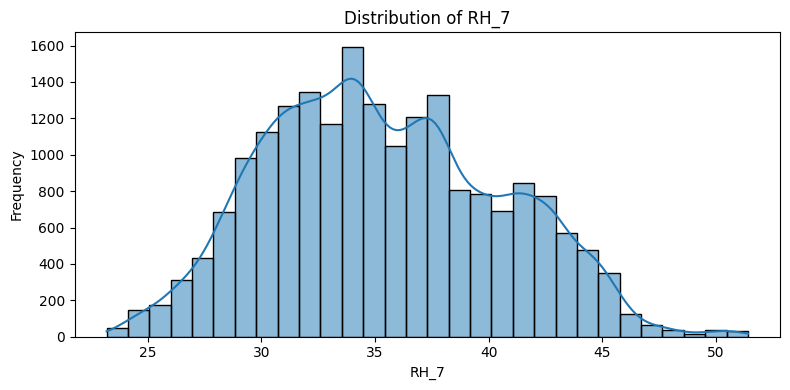

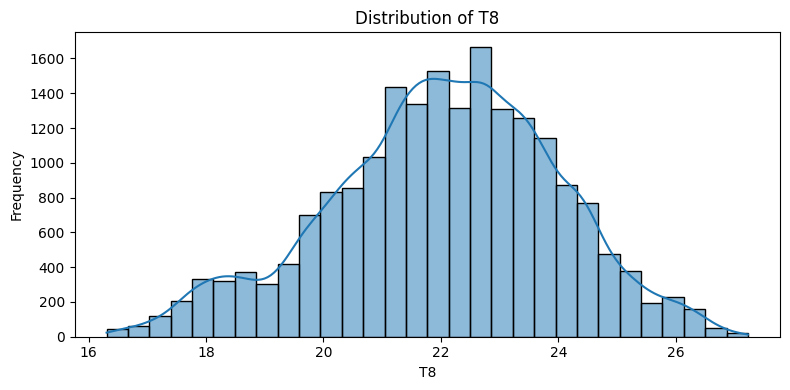

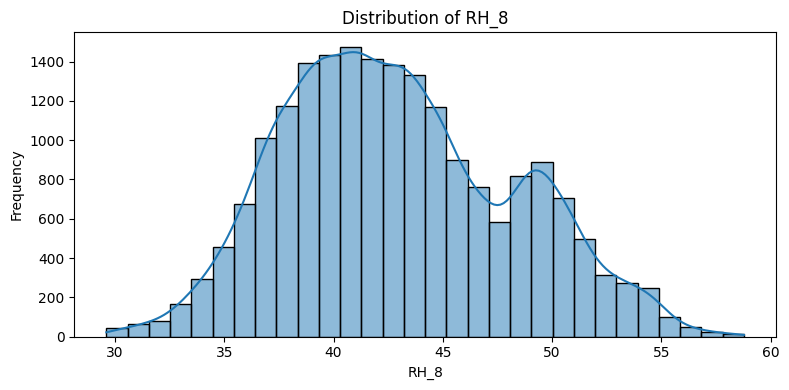

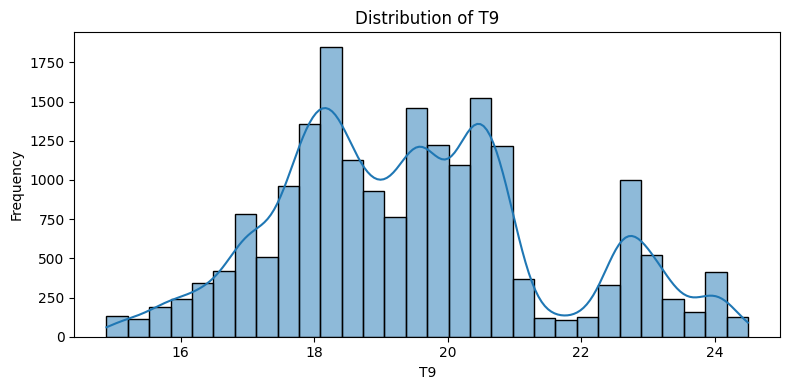

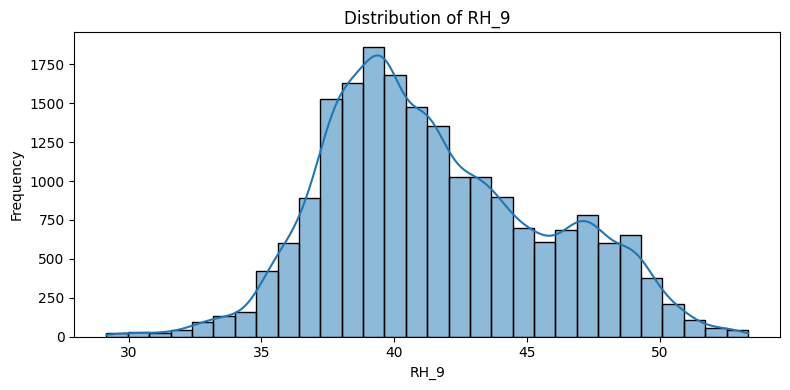

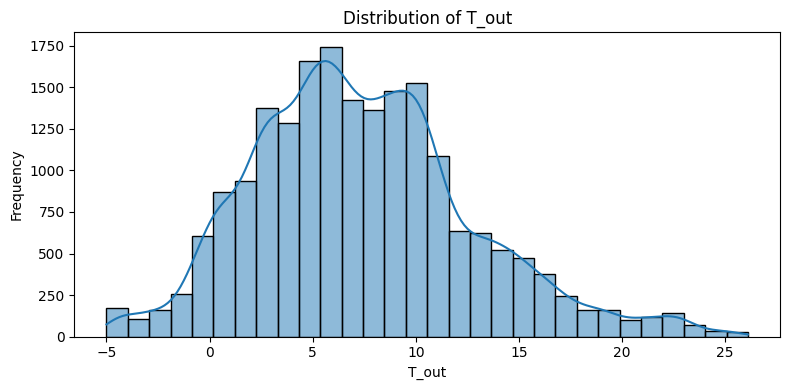

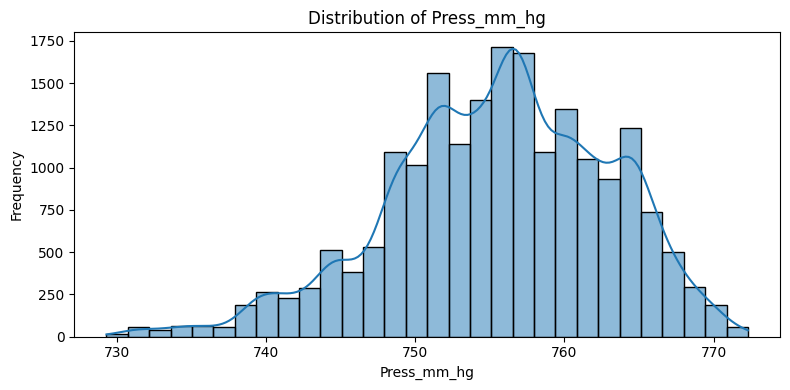

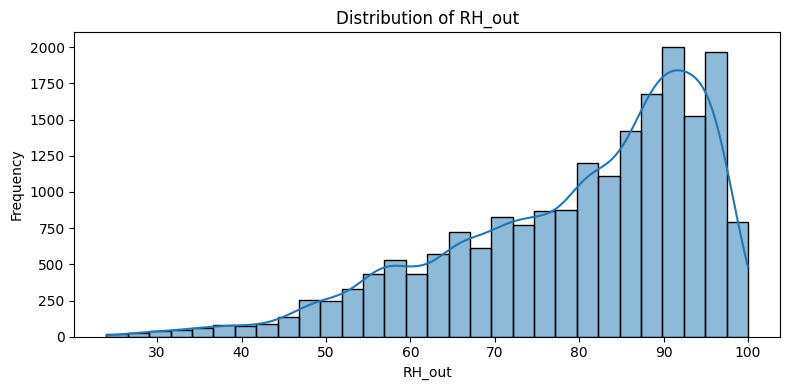

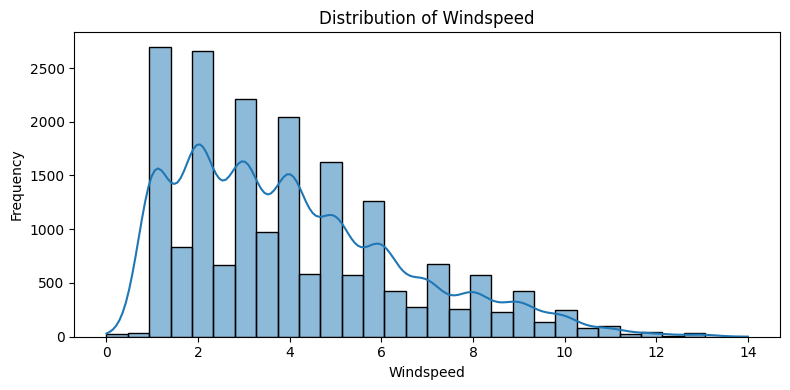

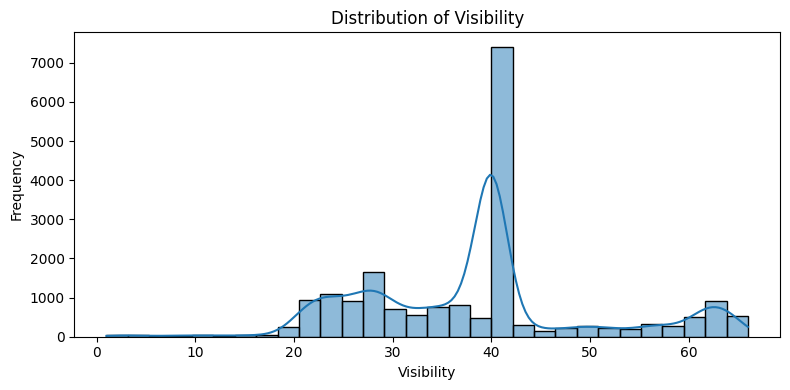

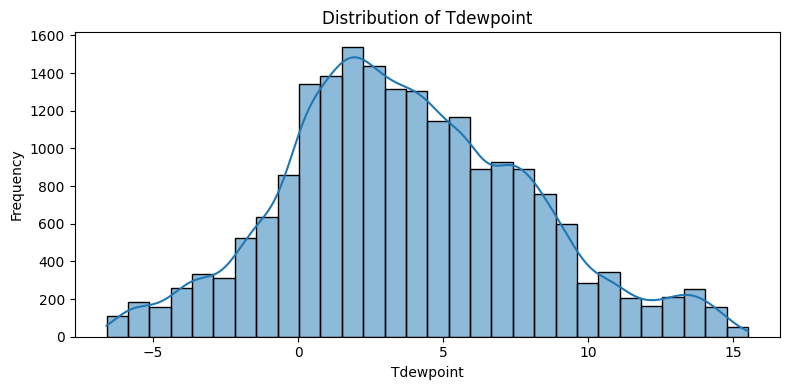

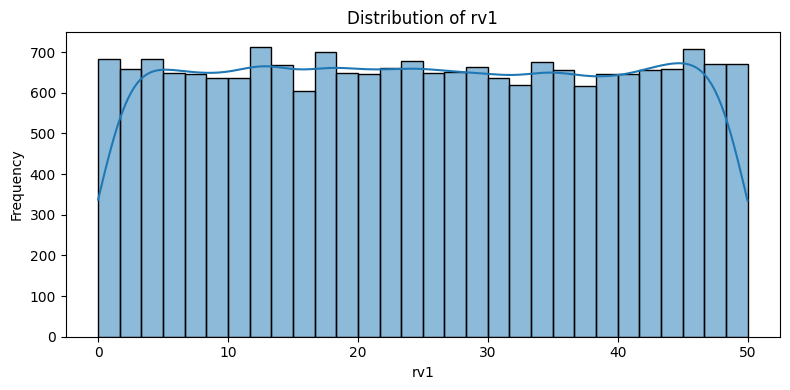

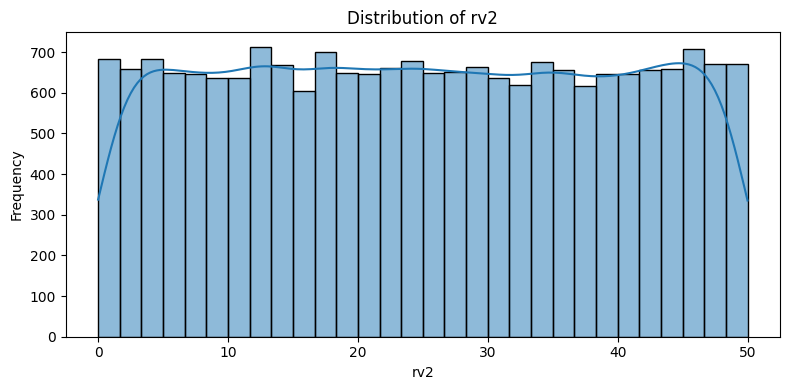

In [5]:
feature_cols = df.select_dtypes(include="number").columns.drop("Appliances")

for col in feature_cols:
    plt.figure(figsize=(8, 4))
    sns.histplot(df[col], bins=30, kde=True)
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.title(f"Distribution of {col}")
    plt.tight_layout()
    plt.show()
    plt.close()

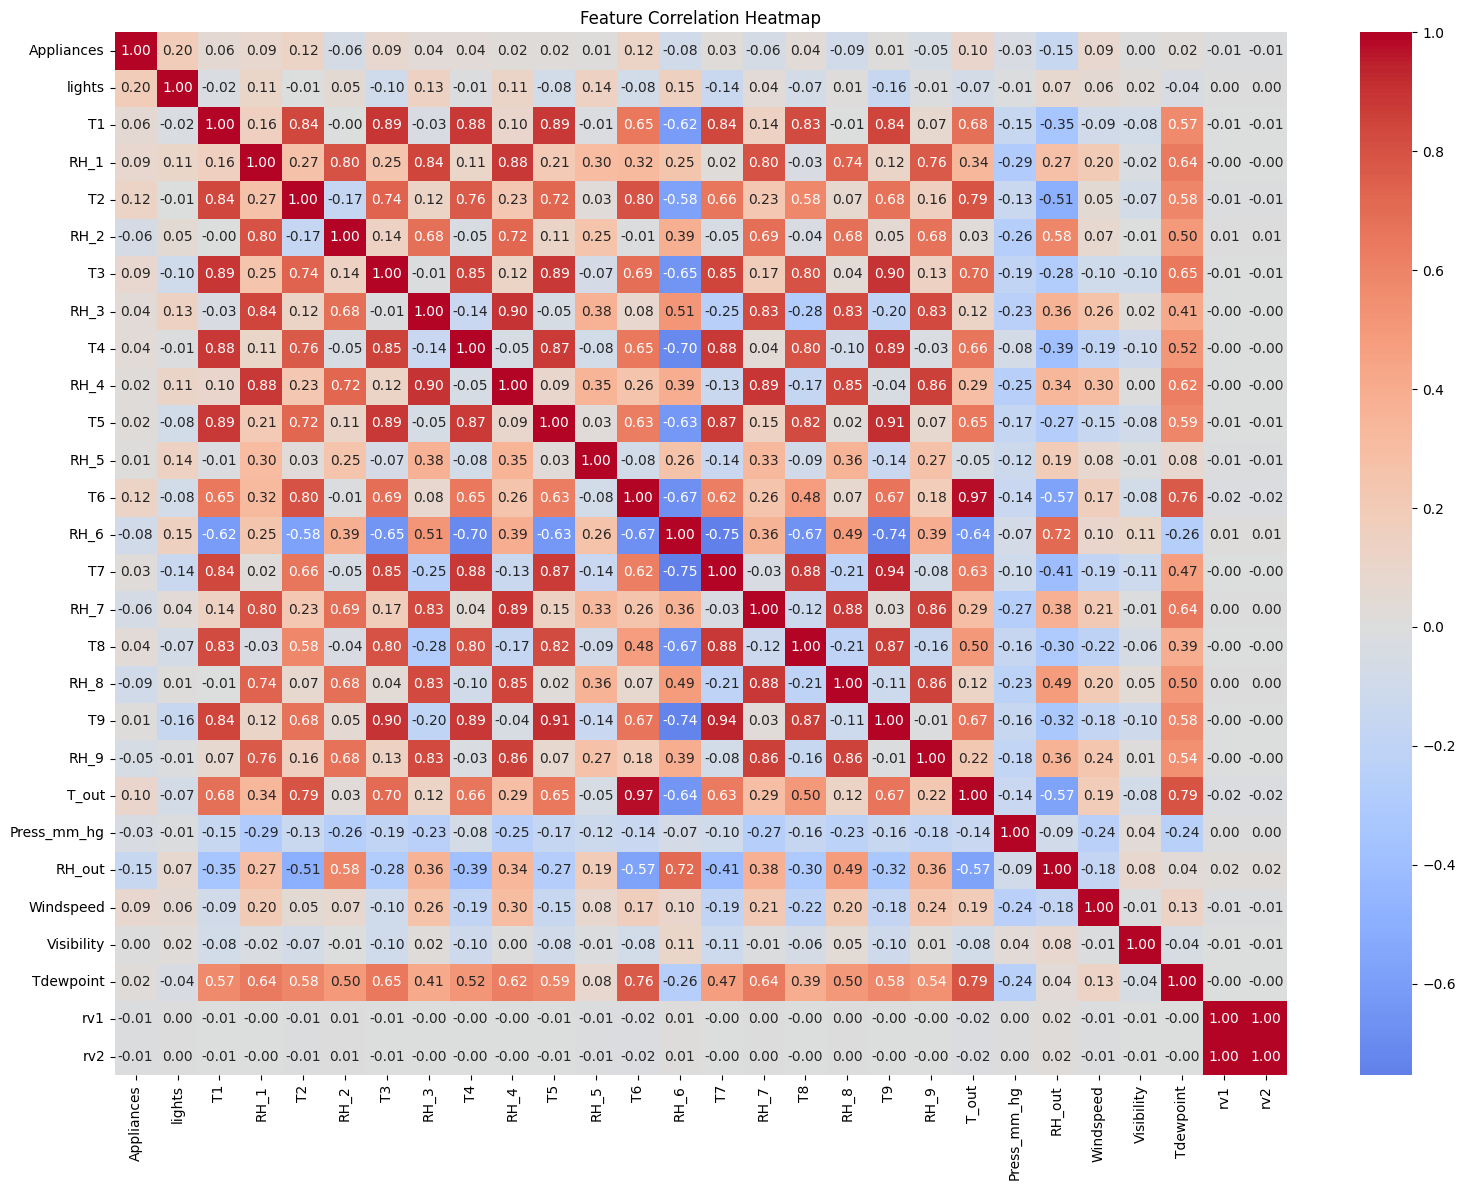

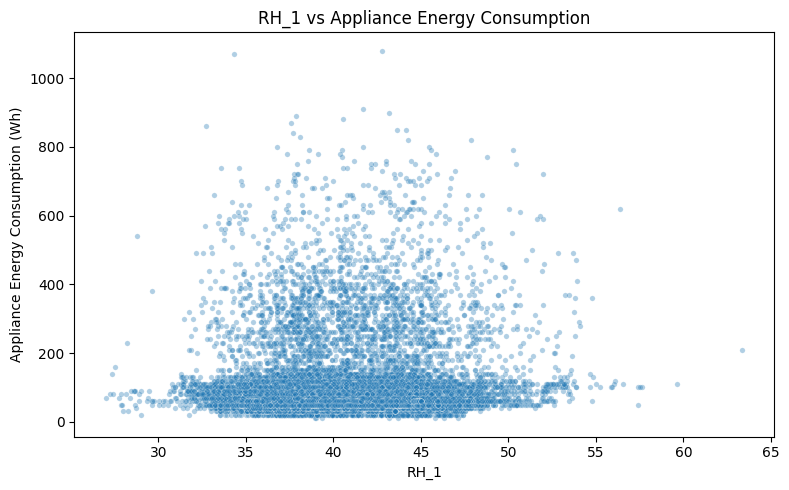

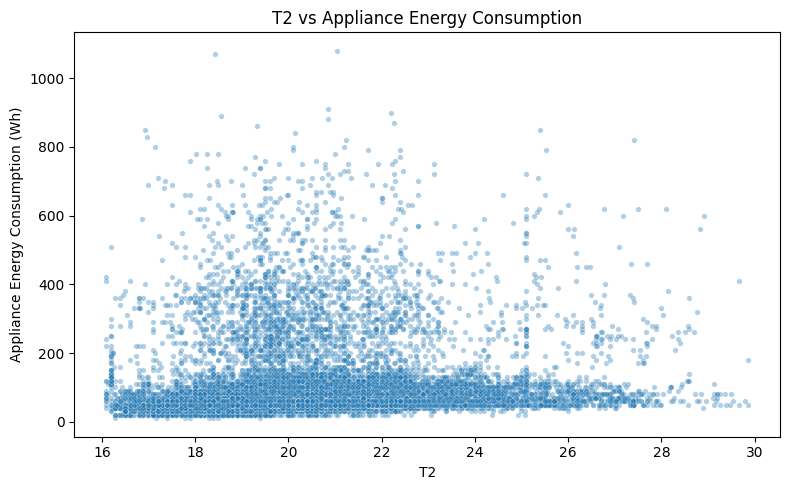

In [6]:
plt.figure(figsize=(16, 12))
corr = df.select_dtypes(include="number").corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

for feature in ["RH_1", "T2"]:
    plt.figure(figsize=(8, 5))
    sns.scatterplot(x=df[feature], y=df["Appliances"], alpha=0.35, s=15)
    plt.xlabel(feature)
    plt.ylabel("Appliance Energy Consumption (Wh)")
    plt.title(f"{feature} vs Appliance Energy Consumption")
    plt.tight_layout()
    plt.show()

## 5. Data Cleaning and Feature Engineering

The team's first regression notebook makes these main preprocessing choices:

- remove the raw `date` column;
- handle missing numeric values with mean imputation;
- apply `log1p` to `lights` because many values are zero;
- inspect outliers and clip predictor outliers using the IQR rule;
- remove redundant highly correlated predictors using a 0.90 absolute-correlation threshold.

Here the same ideas are implemented in a leakage-safe way: preprocessing parameters that must be learned from data are calculated from the **training set only** and then applied to the test set.

In [ ]:
working = df.drop(columns=["date"]).copy()

X_raw = working.drop(columns=["Appliances"])
y = working["Appliances"].copy()

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE
)

print("Training samples:", len(X_train_raw))
print("Testing samples :", len(X_test_raw))

Training samples: 15788
Testing samples : 3947


In [ ]:

# 1. Mean imputation
imputation_values = X_train_raw.mean(numeric_only=True)
X_train = X_train_raw.copy()
X_test = X_test_raw.copy()

for col in X_train.columns:
    if X_train[col].isna().any() or X_test[col].isna().any():
        X_train[col] = X_train[col].fillna(imputation_values[col])
        X_test[col] = X_test[col].fillna(imputation_values[col])

# 2. Log transform for lights, matching the team's approach
X_train["lights"] = np.log1p(X_train["lights"].clip(lower=0))
X_test["lights"] = np.log1p(X_test["lights"].clip(lower=0))

# 3. IQR clipping thresholds learned from training data only
clip_bounds = {}
for col in X_train.columns:
    Q1 = X_train[col].quantile(0.25)
    Q3 = X_train[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    clip_bounds[col] = (lower, upper)
    X_train[col] = X_train[col].clip(lower=lower, upper=upper)
    X_test[col] = X_test[col].clip(lower=lower, upper=upper)

print("Preprocessing completed.")

Preprocessing completed.


## 6. Remove Highly Correlated Predictors

A predictor pair with absolute correlation above 0.90 is treated as highly redundant. For each highly correlated pair, the feature with the **weaker absolute correlation with `Appliances`** is removed. This keeps the same logic as the team's existing feature-engineering notebook, but the correlations are calculated from the training set only.

In [9]:
train_corr = X_train.copy()
train_corr["Appliances"] = y_train.values
corr = train_corr.corr(numeric_only=True)

threshold = 0.90
to_remove = set()

for i in range(len(X_train.columns)):
    for j in range(i + 1, len(X_train.columns)):
        feature1 = X_train.columns[i]
        feature2 = X_train.columns[j]
        correlation = corr.loc[feature1, feature2]

        if abs(correlation) > threshold:
            target_corr_1 = abs(corr.loc[feature1, "Appliances"])
            target_corr_2 = abs(corr.loc[feature2, "Appliances"])

            print(f"{feature1} <-> {feature2}: {correlation:.4f}")

            if target_corr_1 < target_corr_2:
                to_remove.add(feature1)
                print("Removing:", feature1)
            else:
                to_remove.add(feature2)
                print("Removing:", feature2)

X_train = X_train.drop(columns=sorted(to_remove))
X_test = X_test.drop(columns=sorted(to_remove))

print("\nRemoved features:", sorted(to_remove))
print("Remaining features:", X_train.shape[1])
print(X_train.columns.tolist())

T3 <-> T9: 0.9044
Removing: T9
T5 <-> T9: 0.9118
Removing: T9
T6 <-> T_out: 0.9749
Removing: T_out
T7 <-> T9: 0.9453
Removing: T9
rv1 <-> rv2: 1.0000
Removing: rv2

Removed features: ['T9', 'T_out', 'rv2']
Remaining features: 24
['lights', 'T1', 'RH_1', 'T2', 'RH_2', 'T3', 'RH_3', 'T4', 'RH_4', 'T5', 'RH_5', 'T6', 'RH_6', 'T7', 'RH_7', 'T8', 'RH_8', 'RH_9', 'Press_mm_hg', 'RH_out', 'Windspeed', 'Visibility', 'Tdewpoint', 'rv1']


## 7. Standardization

The team's notebook standardizes the predictors before modeling. We do the same, but the scaler is fitted **only on the training data**. This prevents information from the test set from affecting the scaling parameters.

Tree models do not require scaling mathematically, but using the same standardized feature matrix for the five-model comparison keeps the experiment consistent with the team's first five regression algorithms.

In [10]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaled training shape:", X_train_scaled.shape)
print("Scaled testing shape :", X_test_scaled.shape)

Scaled training shape: (15788, 24)
Scaled testing shape : (3947, 24)


## 8. Evaluation Helper

In [11]:
def regression_metrics(model, X_train_data, y_train_data, X_test_data, y_test_data):
    train_pred = model.predict(X_train_data)
    test_pred = model.predict(X_test_data)

    mse = mean_squared_error(y_test_data, test_pred)
    rmse = np.sqrt(mse)

    metrics = {
        "R²": r2_score(y_test_data, test_pred),
        "RMSE": rmse,
        "MAE": mean_absolute_error(y_test_data, test_pred),
        "MSE": mse,
        "Train RMSE": np.sqrt(mean_squared_error(y_train_data, train_pred)),
    }
    return metrics, train_pred, test_pred


def save_meta(path, best_params, best_cv_rmse):
    with open(path, "w", encoding="utf-8") as f:
        json.dump({
            "best_params": best_params,
            "best_cv_rmse": float(best_cv_rmse)
        }, f, indent=4)


def load_meta(path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

results = {}
best_models = {}
cv_summary = {}

# 9. Decision Tree Regressor

A Decision Tree recursively splits the feature space into regions. For regression, the prediction in a leaf is the mean target value of the training samples reaching that leaf.

Main complexity controls tuned here: `max_depth`, `min_samples_split`, and `min_samples_leaf`.

In [12]:
dt_model_path = MODEL_DIR / "decision_tree_appliances_randomsplit.pkl"
dt_meta_path = MODEL_DIR / "decision_tree_appliances_randomsplit.json"

dt_param_grid = {
    "max_depth": [2, 3, 4, 5, 6, 8, 10, 12, 15, 20, None],
    "min_samples_split": [2, 5, 10, 20, 50],
    "min_samples_leaf": [1, 2, 5, 10, 20]
}

if dt_model_path.exists() and dt_meta_path.exists():
    final_dt = joblib.load(dt_model_path)
    dt_meta = load_meta(dt_meta_path)
    print("Loaded saved Decision Tree model.")
else:
    dt_search = GridSearchCV(
        DecisionTreeRegressor(random_state=RANDOM_STATE),
        dt_param_grid,
        scoring="neg_root_mean_squared_error",
        cv=CV,
        n_jobs=-1,
        verbose=1
    )
    dt_search.fit(X_train_scaled, y_train)
    final_dt = dt_search.best_estimator_
    save_meta(dt_meta_path, dt_search.best_params_, -dt_search.best_score_)
    dt_meta = load_meta(dt_meta_path)
    joblib.dump(final_dt, dt_model_path)

print("Best Parameters:", dt_meta["best_params"])
print("Best CV RMSE:", dt_meta["best_cv_rmse"])

dt_metrics, dt_train_pred, dt_pred = regression_metrics(
    final_dt, X_train_scaled, y_train, X_test_scaled, y_test
)
print("\nFinal Decision Tree Regressor")
for k, v in dt_metrics.items():
    print(f"{k}: {v:.6f}")
results["Decision Tree"] = dt_metrics
best_models["Decision Tree"] = final_dt
cv_summary["Decision Tree"] = dt_meta["best_cv_rmse"]

Fitting 5 folds for each of 275 candidates, totalling 1375 fits
Best Parameters: {'max_depth': None, 'min_samples_leaf': 10, 'min_samples_split': 2}
Best CV RMSE: 87.67910089050405

Final Decision Tree Regressor
R²: 0.317591
RMSE: 82.637318
MAE: 40.580676
MSE: 6828.926302
Train RMSE: 63.803305


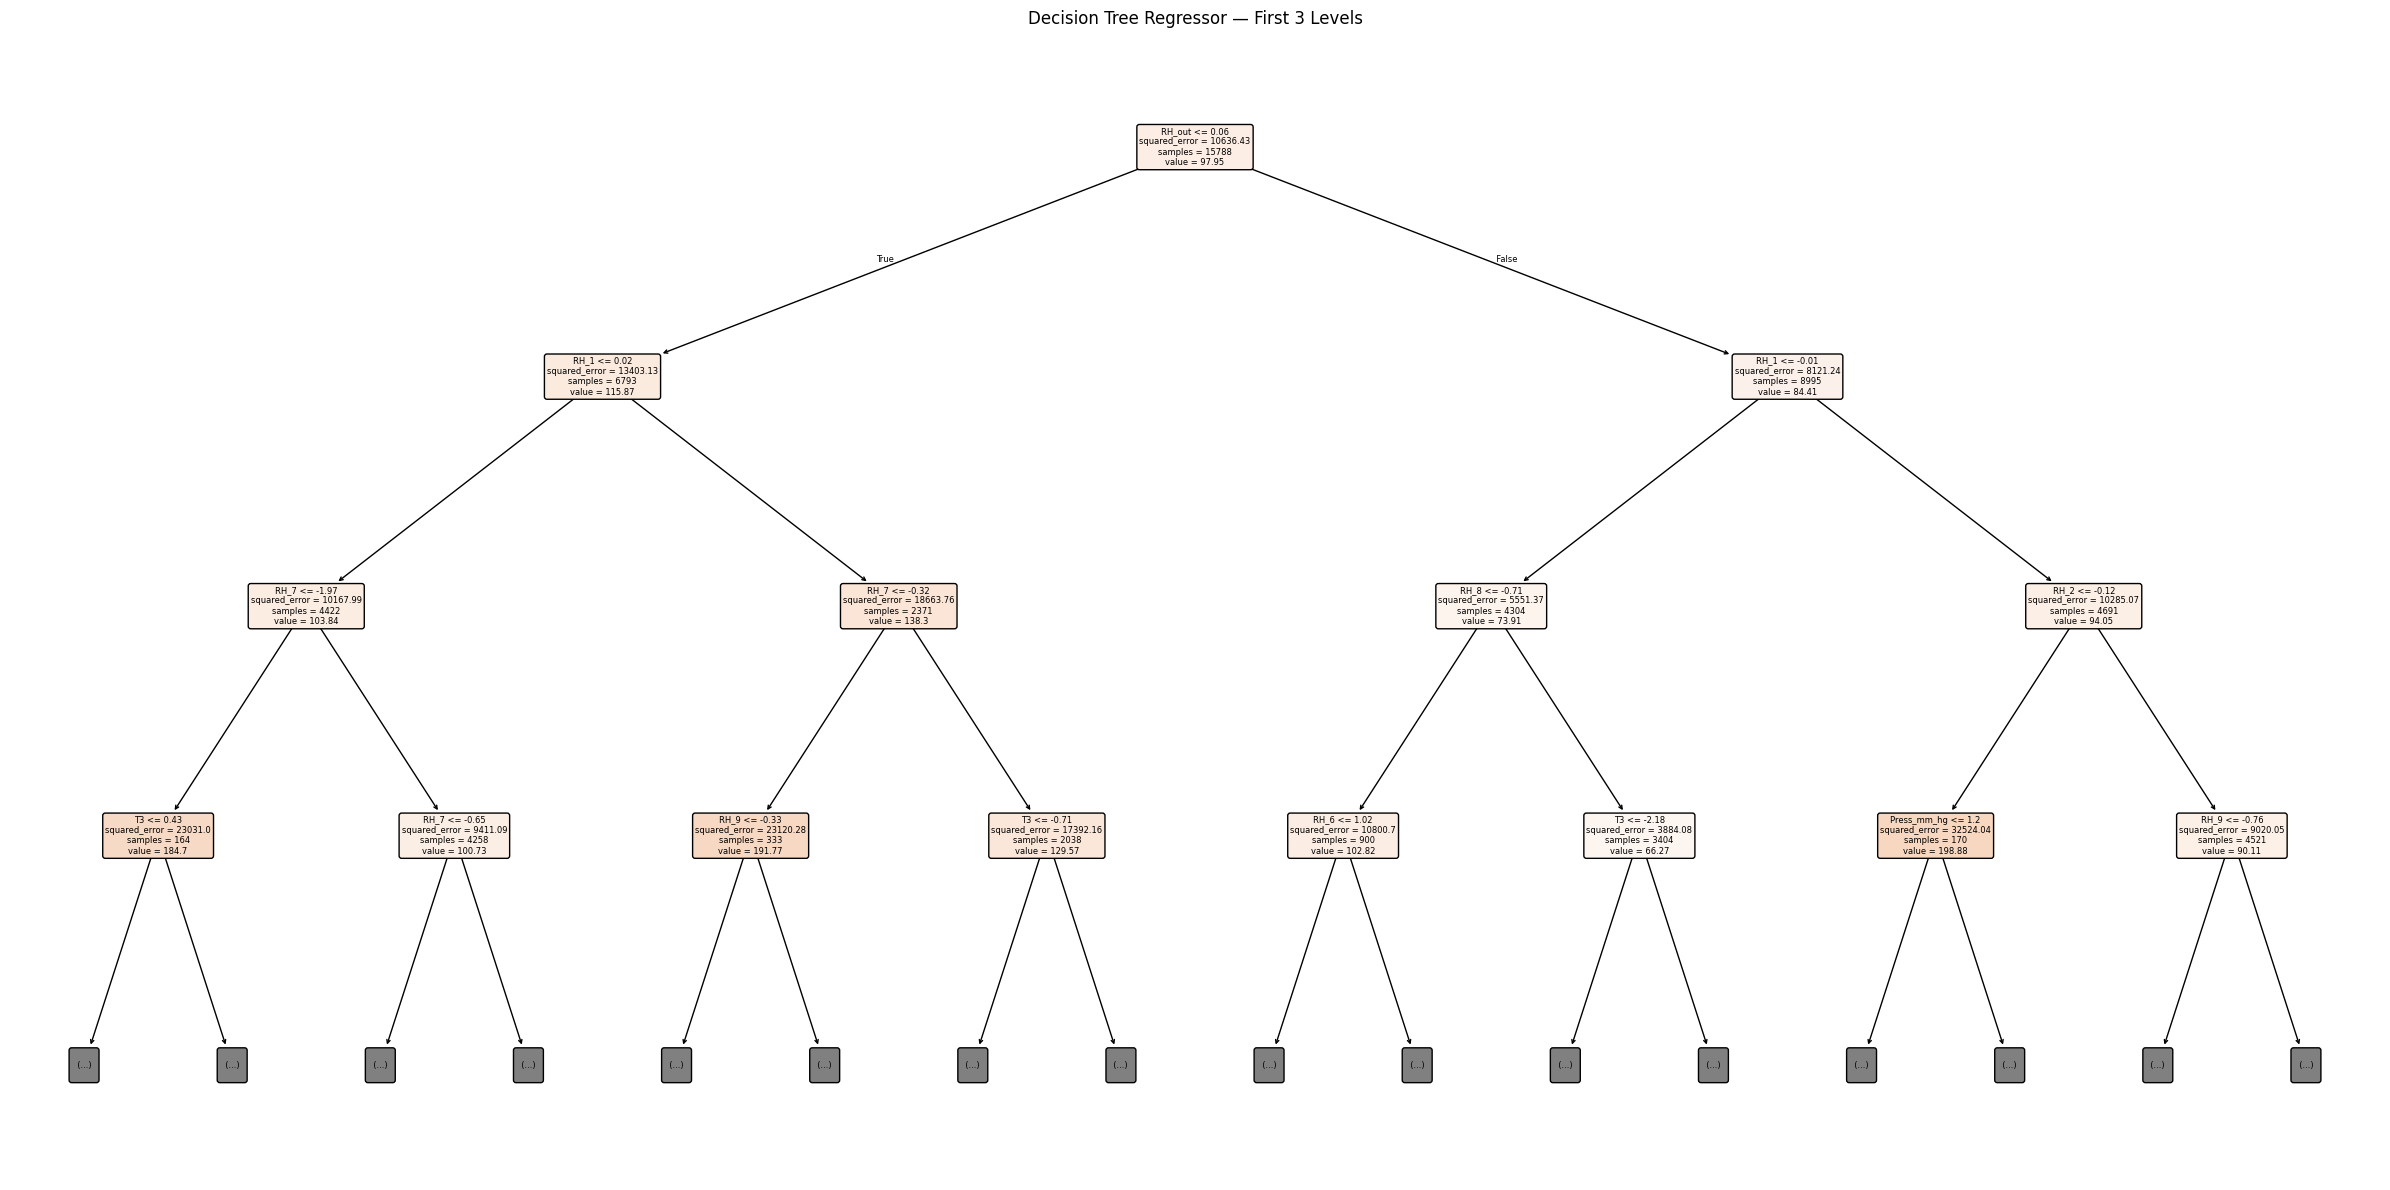

In [13]:
plt.figure(figsize=(24, 12))
plot_tree(
    final_dt,
    feature_names=X_train.columns,
    filled=True,
    rounded=True,
    precision=2,
    max_depth=3
)
plt.title("Decision Tree Regressor — First 3 Levels")
plt.tight_layout()
plt.show()

# 10. Random Forest Regressor

Random Forest combines many decision trees trained with randomness in samples/features. For regression, their predictions are averaged.

Because several hyperparameters interact, `RandomizedSearchCV` is used instead of tuning one parameter at a time.

In [ ]:
rf_model_path = MODEL_DIR / "random_forest_appliances_randomsplit.pkl"
rf_meta_path = MODEL_DIR / "random_forest_appliances_randomsplit.json"

rf_param_distributions = {
    "n_estimators": [100, 150, 200, 250, 300, 400],
    "max_depth": [None, 5, 8, 10, 12, 15, 20, 25],
    "min_samples_split": [2, 5, 10, 20, 50],
    "min_samples_leaf": [1, 2, 5, 10, 20],
    "max_features": [1.0, "sqrt", "log2"]
}

if rf_model_path.exists() and rf_meta_path.exists():
    final_rf = joblib.load(rf_model_path)
    rf_meta = load_meta(rf_meta_path)
    print("Loaded saved Random Forest model.")
else:
    rf_search = RandomizedSearchCV(
        RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=1),
        rf_param_distributions,
        n_iter=30,
        scoring="neg_root_mean_squared_error",
        cv=CV,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=2,
        pre_dispatch="2*n_jobs"
    )
    rf_search.fit(X_train_scaled, y_train)
    final_rf = rf_search.best_estimator_
    save_meta(rf_meta_path, rf_search.best_params_, -rf_search.best_score_)
    rf_meta = load_meta(rf_meta_path)
    joblib.dump(final_rf, rf_model_path)

print("Best Parameters:", rf_meta["best_params"])
print("Best CV RMSE:", rf_meta["best_cv_rmse"])

rf_metrics, rf_train_pred, rf_pred = regression_metrics(
    final_rf, X_train_scaled, y_train, X_test_scaled, y_test
)
print("\nFinal Random Forest Regressor")
for k, v in rf_metrics.items():
    print(f"{k}: {v:.6f}")
print(f"RMSE Gap: {rf_metrics['RMSE'] - rf_metrics['Train RMSE']:.6f}")
results["Random Forest"] = rf_metrics
best_models["Random Forest"] = final_rf
cv_summary["Random Forest"] = rf_meta["best_cv_rmse"]

Fitting 5 folds for each of 30 candidates, totalling 150 fits


In [ ]:
rf_importance = pd.Series(final_rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 7))
rf_importance.head(15).sort_values().plot(kind="barh")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Random Forest — Top 15 Feature Importances")
plt.tight_layout()
plt.show()

# 11. Gradient Boosting Regressor

Gradient Boosting builds trees sequentially. Each new tree attempts to reduce the errors made by the existing ensemble.

Important hyperparameters include `n_estimators`, `learning_rate`, tree depth, minimum sample constraints, and `subsample`.

In [ ]:
gb_model_path = MODEL_DIR / "gradient_boosting_appliances_randomsplit.pkl"
gb_meta_path = MODEL_DIR / "gradient_boosting_appliances_randomsplit.json"

gb_param_distributions = {
    "n_estimators": [100, 150, 200, 250, 300, 400],
    "learning_rate": [0.01, 0.03, 0.05, 0.08, 0.1, 0.15],
    "max_depth": [2, 3, 4, 5],
    "min_samples_split": [2, 5, 10, 20, 50],
    "min_samples_leaf": [1, 2, 5, 10, 20],
    "subsample": [0.8, 1.0]
}

if gb_model_path.exists() and gb_meta_path.exists():
    final_gb = joblib.load(gb_model_path)
    gb_meta = load_meta(gb_meta_path)
    print("Loaded saved Gradient Boosting model.")
else:
    gb_search = RandomizedSearchCV(
        GradientBoostingRegressor(random_state=RANDOM_STATE),
        gb_param_distributions,
        n_iter=30,
        scoring="neg_root_mean_squared_error",
        cv=CV,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=2,
        pre_dispatch="2*n_jobs"
    )
    gb_search.fit(X_train_scaled, y_train)
    final_gb = gb_search.best_estimator_
    save_meta(gb_meta_path, gb_search.best_params_, -gb_search.best_score_)
    gb_meta = load_meta(gb_meta_path)
    joblib.dump(final_gb, gb_model_path)

print("Best Parameters:", gb_meta["best_params"])
print("Best CV RMSE:", gb_meta["best_cv_rmse"])

gb_metrics, gb_train_pred, gb_pred = regression_metrics(
    final_gb, X_train_scaled, y_train, X_test_scaled, y_test
)
print("\nFinal Gradient Boosting Regressor")
for k, v in gb_metrics.items():
    print(f"{k}: {v:.6f}")
print(f"RMSE Gap: {gb_metrics['RMSE'] - gb_metrics['Train RMSE']:.6f}")
results["Gradient Boosting"] = gb_metrics
best_models["Gradient Boosting"] = final_gb
cv_summary["Gradient Boosting"] = gb_meta["best_cv_rmse"]

# 12. Support Vector Regressor (SVR)

SVR is sensitive to feature scaling, and the data is already standardized using the common training-only scaler above. A compact randomized search tunes `kernel`, `C`, `epsilon`, and `gamma`.

`RBF` is useful when the relationship between predictors and the target is nonlinear.

In [ ]:
svr_model_path = MODEL_DIR / "svr_appliances_randomsplit.pkl"
svr_meta_path = MODEL_DIR / "svr_appliances_randomsplit.json"

svr_param_distributions = {
    "kernel": ["linear", "rbf"],
    "C": [0.1, 1, 3, 10, 30, 100],
    "epsilon": [0.01, 0.05, 0.1, 0.2, 0.5],
    "gamma": ["scale", "auto", 0.001, 0.01, 0.1]
}

if svr_model_path.exists() and svr_meta_path.exists():
    final_svr = joblib.load(svr_model_path)
    svr_meta = load_meta(svr_meta_path)
    print("Loaded saved SVR model.")
else:
    svr_search = RandomizedSearchCV(
        SVR(),
        svr_param_distributions,
        n_iter=12,
        scoring="neg_root_mean_squared_error",
        cv=CV,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=2,
        pre_dispatch="2*n_jobs"
    )
    svr_search.fit(X_train_scaled, y_train)
    final_svr = svr_search.best_estimator_
    save_meta(svr_meta_path, svr_search.best_params_, -svr_search.best_score_)
    svr_meta = load_meta(svr_meta_path)
    joblib.dump(final_svr, svr_model_path)

print("Best Parameters:", svr_meta["best_params"])
print("Best CV RMSE:", svr_meta["best_cv_rmse"])

svr_metrics, svr_train_pred, svr_pred = regression_metrics(
    final_svr, X_train_scaled, y_train, X_test_scaled, y_test
)
print("\nFinal Support Vector Regressor")
for k, v in svr_metrics.items():
    print(f"{k}: {v:.6f}")
print(f"RMSE Gap: {svr_metrics['RMSE'] - svr_metrics['Train RMSE']:.6f}")
results["SVR"] = svr_metrics
best_models["SVR"] = final_svr
cv_summary["SVR"] = svr_meta["best_cv_rmse"]

# 13. K-Nearest Neighbors Regressor

KNN predicts a target from nearby training observations. Because distance is central to KNN, standardization is important.

The main parameters tuned are `n_neighbors`, `weights`, and the Minkowski distance parameter `p`.

In [ ]:
knn_model_path = MODEL_DIR / "knn_appliances_randomsplit.pkl"
knn_meta_path = MODEL_DIR / "knn_appliances_randomsplit.json"

knn_param_grid = {
    "n_neighbors": [3, 5, 7, 9, 11, 15, 20, 30, 40],
    "weights": ["uniform", "distance"],
    "p": [1, 2]
}

if knn_model_path.exists() and knn_meta_path.exists():
    final_knn = joblib.load(knn_model_path)
    knn_meta = load_meta(knn_meta_path)
    print("Loaded saved KNN model.")
else:
    knn_search = GridSearchCV(
        KNeighborsRegressor(),
        knn_param_grid,
        scoring="neg_root_mean_squared_error",
        cv=CV,
        n_jobs=-1,
        verbose=1
    )
    knn_search.fit(X_train_scaled, y_train)
    final_knn = knn_search.best_estimator_
    save_meta(knn_meta_path, knn_search.best_params_, -knn_search.best_score_)
    knn_meta = load_meta(knn_meta_path)
    joblib.dump(final_knn, knn_model_path)

print("Best Parameters:", knn_meta["best_params"])
print("Best CV RMSE:", knn_meta["best_cv_rmse"])

knn_metrics, knn_train_pred, knn_pred = regression_metrics(
    final_knn, X_train_scaled, y_train, X_test_scaled, y_test
)
print("\nFinal K-Nearest Neighbors Regressor")
for k, v in knn_metrics.items():
    print(f"{k}: {v:.6f}")
print(f"RMSE Gap: {knn_metrics['RMSE'] - knn_metrics['Train RMSE']:.6f}")
results["KNN"] = knn_metrics
best_models["KNN"] = final_knn
cv_summary["KNN"] = knn_meta["best_cv_rmse"]

# 14. Final Comparison of All Five Models

All five models are evaluated on the **same untouched test set**. Higher R² is better; lower RMSE, MAE, and MSE are better.

In [ ]:
comparison_df = pd.DataFrame(results).T
comparison_df = comparison_df[["R²", "RMSE", "MAE", "MSE", "Train RMSE"]]
comparison_df = comparison_df.sort_values("R²", ascending=False)
comparison_df

In [ ]:
cv_df = pd.DataFrame.from_dict(cv_summary, orient="index", columns=["Best CV RMSE"])
cv_df = cv_df.sort_values("Best CV RMSE")
cv_df

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

comparison_df["RMSE"].plot(kind="bar", ax=axes[0])
axes[0].set_title("Test RMSE Comparison")
axes[0].set_xlabel("Model")
axes[0].set_ylabel("RMSE")
axes[0].tick_params(axis="x", rotation=45)

comparison_df["R²"].plot(kind="bar", ax=axes[1])
axes[1].set_title("Test R² Comparison")
axes[1].set_xlabel("Model")
axes[1].set_ylabel("R²")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

# 15. Two Best Models — 5-Fold Cross-Validated R²

The project requires 5-fold cross-validated R² for the two best-performing regression models. These scores are calculated on the training portion only; the final held-out test set remains untouched.

In [ ]:
best_two_names = comparison_df.head(2).index.tolist()
cv_r2_rows = []

for model_name in best_two_names:
    model = best_models[model_name]
    scores = cross_val_score(
        model,
        X_train_scaled,
        y_train,
        cv=CV,
        scoring="r2",
        n_jobs=-1
    )
    row = {f"Fold {i+1}": scores[i] for i in range(5)}
    row["Mean CV R²"] = scores.mean()
    row["Std CV R²"] = scores.std()
    row["Model"] = model_name
    cv_r2_rows.append(row)

cv_r2_df = pd.DataFrame(cv_r2_rows).set_index("Model")
cv_r2_df

# 16. Best Model — Predicted vs Actual and Residuals

In [ ]:
best_model_name = comparison_df.index[0]
best_model = best_models[best_model_name]
best_metrics, best_train_pred, best_test_pred = regression_metrics(
    best_model, X_train_scaled, y_train, X_test_scaled, y_test
)

print("Best model:", best_model_name)
print("\nFinal test metrics:")
for k, v in best_metrics.items():
    print(f"{k}: {v:.6f}")

In [ ]:
plt.figure(figsize=(7, 6))
plt.scatter(y_test, best_test_pred, alpha=0.35, s=12)
min_value = min(y_test.min(), best_test_pred.min())
max_value = max(y_test.max(), best_test_pred.max())
plt.plot([min_value, max_value], [min_value, max_value], linestyle="--")
plt.xlabel("Actual Appliances Energy (Wh)")
plt.ylabel("Predicted Appliances Energy (Wh)")
plt.title(f"Predicted vs Actual — {best_model_name}")
plt.tight_layout()
plt.show()

In [ ]:
residuals = y_test - best_test_pred

plt.figure(figsize=(8, 5))
plt.scatter(best_test_pred, residuals, alpha=0.35, s=12)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted Appliances Energy (Wh)")
plt.ylabel("Residual (Actual - Predicted)")
plt.title(f"Residual Plot — {best_model_name}")
plt.tight_layout()
plt.show()

# 17. Conclusion

The five regression models use the same preprocessed feature matrix, the same 80:20 train/test split, and the same held-out test set. Hyperparameter tuning is performed only on the training data using 5-fold cross-validation. Final model performance is reported using R², RMSE, MAE, and MSE.

The resulting five-model table can be combined directly with the team's Linear Regression, Ridge, Lasso, ElasticNet, and Polynomial Regression results once those models use the same preprocessing and split.